In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [49]:
df=pd.read_csv('patient_data.csv')

In [50]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [51]:
df

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,Female,35-50,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1821,Male,51-64,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1822,Female,51-64,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL
1823,Male,65+,Yes,No,No,Sever,No,No,No,>5 Years,111 - 120,70 - 80,No,NORMAL


In [52]:
df.head(5)

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [53]:
df.shape

(1825, 14)

In [54]:
#Missing values
print(df.isnull().sum())

C                  0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64


In [55]:
print(df.duplicated().sum())

476


In [56]:
df.describe()

,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
count,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825,1825
unique,2,4,2,2,3,3,2,2,3,3,5,5,2,6
top,Female,51-64,Yes,No,No,Moderate,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
freq,913,475,1657,984,744,697,976,940,984,625,1008,708,984,648


In [57]:
df['Stages'].value_counts()

,count
Stages,
HYPERTENSION (Stage-1),648
HYPERTENSION (Stage-2),599
NORMAL,336
HYPERTENSIVE CRISIS,240
HYPERTENSION (Stage-2).,1
HYPERTENSIVE CRISI,1


In [58]:
# (This fixes the 'Yes ' vs 'Yes' and 'No ' vs 'No' issues)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

In [59]:
df.rename(columns={'C':'Gender'},inplace=True)

In [60]:
df['TakeMedication'] = df['TakeMedication'].replace({'Yes': 1, 'No': 0})
df['NoseBleeding'] = df['NoseBleeding'].replace({'Yes': 1, 'No': 0})
df['Systolic'] = df['Systolic'].replace({'121-130': 125})
df['Systolic'] = df['Systolic'].replace({'100+': 100})
df['Diastolic'] = df['Diastolic'].replace({'130+': '130 - 140'})

In [61]:
df['Stages'] = df['Stages'].replace({
    'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS'
})

In [62]:
df = df.drop_duplicates()


In [63]:
#After removing duplicates
df.shape

(1348, 14)

In [64]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['History']=le.fit_transform(df['History'])
df['Patient']=le.fit_transform(df['Patient'])
df['TakeMedication']=le.fit_transform(df['TakeMedication'])
df['BreathShortness']=le.fit_transform(df['BreathShortness'])
df['VisualChanges']=le.fit_transform(df['VisualChanges'])
df['NoseBleeding']=le.fit_transform(df['NoseBleeding'])
df['ControlledDiet']=le.fit_transform(df['ControlledDiet'])
df['Whendiagnoused']=le.fit_transform(df['Whendiagnoused'])
df['Stages']=le.fit_transform(df['Stages'])
df['Severity']=le.fit_transform(df['Severity'])

In [65]:
df

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,1,18-34,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
1,0,18-34,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
2,1,35-50,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
3,0,35-50,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
4,1,51-64,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,0,35-50,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1597,1,51-64,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1598,0,51-64,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1599,1,65+,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3


In [66]:
df.select_dtypes(include='object').columns

Index(['Age', 'Systolic', 'Diastolic'], dtype='object')

In [67]:
df = df.copy()

# Fix Age column
df['Age'] = df['Age'].str.strip()

df['Age'] = df['Age'].map({
    '18-34': 1,
    '35-50': 2,
    '51-64': 3,
    '65+': 4
})

# Check if any NaN created
print(df['Age'].isnull().sum())

0


In [68]:
df

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,1,1,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
1,0,1,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
2,1,2,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
3,0,2,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
4,1,3,1,0,0,0,0,0,0,1,111 - 120,81 - 90,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,0,2,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1597,1,3,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1598,0,3,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3
1599,1,4,1,0,0,2,0,0,0,2,111 - 120,70 - 80,0,3


In [69]:
df.select_dtypes(include='object').columns

Index(['Systolic', 'Diastolic'], dtype='object')

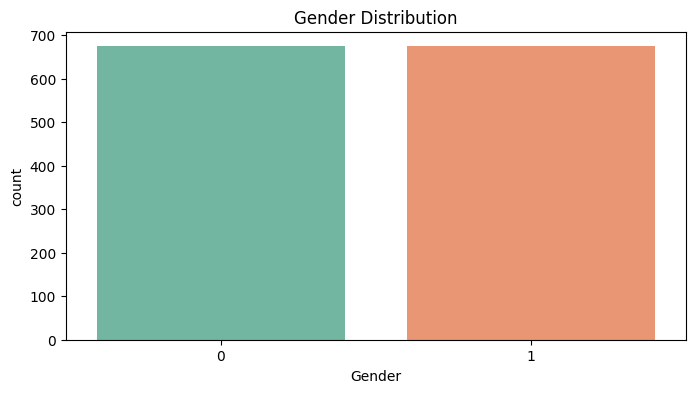

In [70]:
#Data Visualisation
#Count of each categorical feature
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Gender', hue='Gender', palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.show()

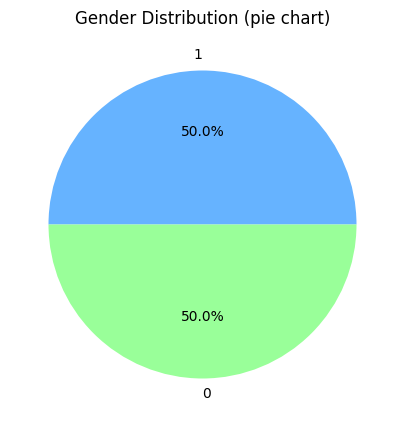

In [71]:
#Pie chart for Gender
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), colors=['#66b3ff', '#99ff99'])
plt.title('Gender Distribution (pie chart)')
plt.ylabel("")
plt.show()

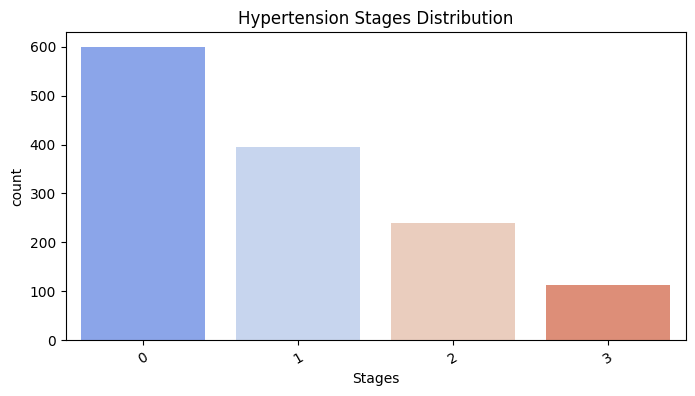

In [72]:
#Hypertension Stages Distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Stages", palette= "coolwarm")
plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

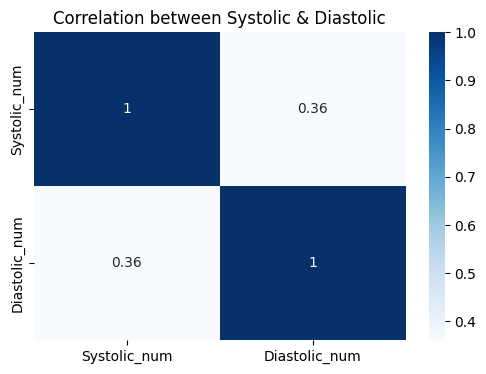

In [73]:
# Heatmap on encoded numeric BP only (after midpoint conversion)
def range_to_midpoint(val):
    if isinstance(val, str):
        if "-" in val:
            start, end = val.split("-")
            return (int(start.strip()) + int(end.strip()))/2
        elif "+" in val:
            return int(val.replace("+","").strip())
    elif isinstance(val, (int, float)):
        return val
    return np.nan

df['Systolic_num'] = df['Systolic'].apply(range_to_midpoint)
df['Diastolic_num'] = df['Diastolic'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(df[['Systolic_num','Diastolic_num']].corr(), annot=True, cmap="Blues")
plt.title("Correlation between Systolic & Diastolic")
plt.show()

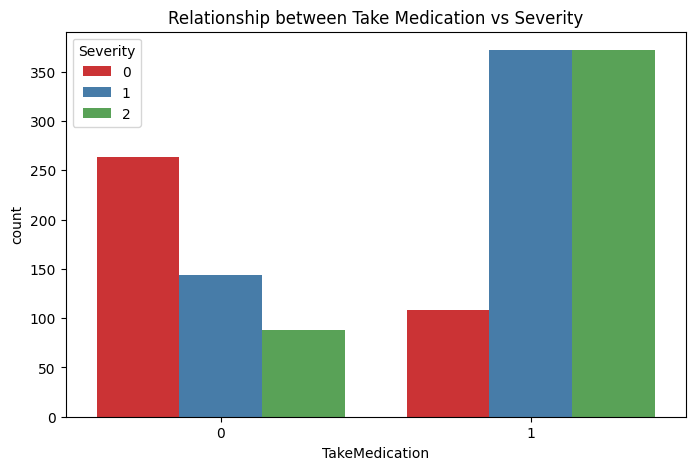

In [74]:
# Relationship between Take Medication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data =df, x='TakeMedication', hue='Severity', palette="Set1")
plt.title("Relationship between Take Medication vs Severity")
plt.show()


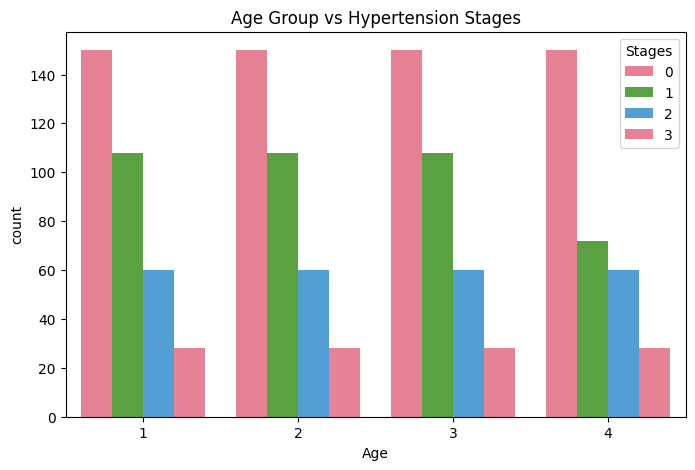

In [75]:
# Age Group vs Hypertension Stages
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age', hue='Stages', palette="husl")
plt.title("Age Group vs Hypertension Stages")
plt.show()


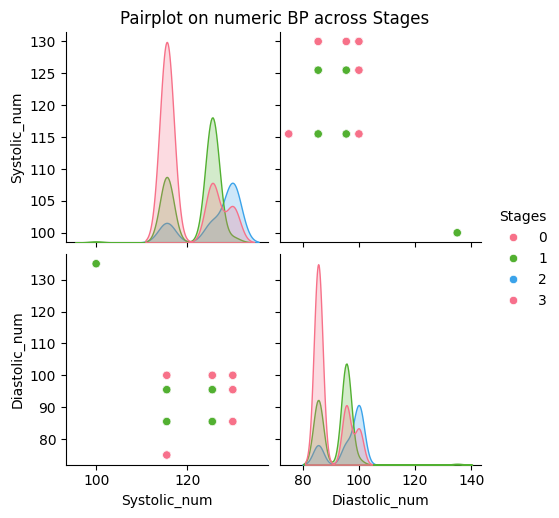

In [76]:
# Pairplot on numeric BP with Stages as hue
sns.pairplot(df[['Systolic_num', 'Diastolic_num', 'Stages']], hue='Stages', diag_kind='kde', palette='husl')
plt.suptitle('Pairplot on numeric BP across Stages ', y=1.02)
plt.show()

In [77]:
print(df['Stages'].value_counts())

Stages
0    600
1    396
2    240
3    112
Name: count, dtype: int64


In [78]:
x = df.drop(['Stages', 'Systolic', 'Diastolic'], axis=1)
y = df['Stages']

Data Splitting

In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split (x,y,test_size=0.2,random_state=42)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1348 entries, 0 to 1600
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           1348 non-null   int64  
 1   Age              1348 non-null   int64  
 2   History          1348 non-null   int64  
 3   Patient          1348 non-null   int64  
 4   TakeMedication   1348 non-null   int64  
 5   Severity         1348 non-null   int64  
 6   BreathShortness  1348 non-null   int64  
 7   VisualChanges    1348 non-null   int64  
 8   NoseBleeding     1348 non-null   int64  
 9   Whendiagnoused   1348 non-null   int64  
 10  Systolic         1348 non-null   object 
 11  Diastolic        1348 non-null   object 
 12  ControlledDiet   1348 non-null   int64  
 13  Stages           1348 non-null   int64  
 14  Systolic_num     1348 non-null   float64
 15  Diastolic_num    1348 non-null   float64
dtypes: float64(2), int64(12), object(2)
memory usage: 179.0+ KB


Scaling

In [81]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

In [82]:
len(x_train)

1078

In [83]:
len(x_test)

270

In [84]:
x_train_sc

array([[ 1.02632029, -1.32527225,  0.2038281 , ..., -0.93355652,
        -0.92360628, -0.60496667],
       [ 1.02632029,  0.49349731,  0.2038281 , ...,  1.07117242,
         1.49018569,  0.72487442],
       [ 1.02632029, -0.41588747,  0.2038281 , ..., -0.93355652,
        -0.92360628, -0.60496667],
       ...,
       [ 1.02632029, -0.41588747, -4.90609493, ..., -0.93355652,
        -0.92360628, -2.00129981],
       [ 1.02632029,  0.49349731,  0.2038281 , ...,  1.07117242,
         0.74107784,  0.72487442],
       [ 1.02632029, -0.41588747,  0.2038281 , ..., -0.93355652,
         1.49018569, -0.60496667]])

Model Training

Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(x_train_sc,y_train)
y_predict=model_lr.predict(x_test_sc)
print(accuracy_score(y_test,y_predict))
print(classification_report(y_test,y_predict))

0.9074074074074074
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       0.84      0.87      0.86        85
           2       0.76      0.71      0.74        49
           3       1.00      1.00      1.00        23

    accuracy                           0.91       270
   macro avg       0.90      0.90      0.90       270
weighted avg       0.91      0.91      0.91       270



Decision Tree

In [86]:
from sklearn.tree import DecisionTreeClassifier
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train_sc,y_train)
y_predict=model_dt.predict(x_test_sc)
print(accuracy_score(y_test,y_predict))
print(classification_report(y_test,y_predict))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



Random Forest Classifier

In [87]:
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(n_estimators=300,random_state=42)
model_rf.fit(x_train_sc,y_train)
y_predict=model_rf.predict(x_test_sc)
print(accuracy_score(y_test,y_predict))
print(classification_report(y_test,y_predict))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



Support Vector Machine

In [88]:
from sklearn.svm import SVC

model_svm = SVC()
model_svm.fit(x_train_sc, y_train)

y_predict_svm = model_svm.predict(x_test_sc)

print(accuracy_score(y_test, y_predict_svm))
print(classification_report(y_test, y_predict_svm))

0.9592592592592593
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      0.87      0.93        85
           2       0.82      1.00      0.90        49
           3       1.00      1.00      1.00        23

    accuracy                           0.96       270
   macro avg       0.95      0.97      0.96       270
weighted avg       0.97      0.96      0.96       270



K Nearest Neighbour

In [89]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(x_train_sc, y_train)

y_pred = knn.predict(x_test_sc)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.9185185185185185
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       0.91      0.82      0.86        85
           2       0.74      0.86      0.79        49
           3       1.00      1.00      1.00        23

    accuracy                           0.92       270
   macro avg       0.91      0.92      0.91       270
weighted avg       0.92      0.92      0.92       270



Gaussian Naive Bayes

In [90]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

model_nb = GaussianNB()

model_nb.fit(x_train_sc, y_train)

y_predict_nb = model_nb.predict(x_test_sc)

print("Accuracy:", accuracy_score(y_test, y_predict_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_predict_nb))

Accuracy: 0.8444444444444444

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      0.51      0.67        85
           2       0.54      1.00      0.70        49
           3       1.00      1.00      1.00        23

    accuracy                           0.84       270
   macro avg       0.88      0.88      0.84       270
weighted avg       0.92      0.84      0.84       270



In [91]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the XGBoost classifier
model_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(x_train_sc, y_train)

# Make predictions
y_predict = model_xgb.predict(x_test_sc)

# Evaluate the model
print(accuracy_score(y_test, y_predict))
print(classification_report(y_test, y_predict))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



Hyperparameter Tuning

Logistic Regression

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

log_model = LogisticRegression(max_iter=500)

grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train_sc, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test_sc)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Test Accuracy: 0.9074074074074074

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       0.84      0.87      0.86        85
           2       0.76      0.71      0.74        49
           3       1.00      1.00      1.00        23

    accuracy                           0.91       270
   macro avg       0.90      0.90      0.90       270
weighted avg       0.91      0.91      0.91       270



Support Vector Machine

In [93]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC(random_state=42)

grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train_sc, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test_sc)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



Decision Tree

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



RadomForestClassifier

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        23

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



KNearestNeighbour

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train_sc, y_train)

print("Best Parameters:", grid_search.best_params_)
best_knn = grid_search.best_estimator_

y_pred = best_knn.predict(x_test_sc)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Tuned Accuracy: 0.9925925925925926
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      0.98      0.99        85
           2       0.96      1.00      0.98        49
           3       1.00      1.00      1.00        23

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



Gaussian Naive Bayes

In [97]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Parameter grid
param_grid = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

# Model
gnb = GaussianNB()

# GridSearch
grid_search = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
grid_search.fit(x_train_sc, y_train)

print("Best Parameter:", grid_search.best_params_)

# Best model
best_gnb = grid_search.best_estimator_

# Predict
y_pred = best_gnb.predict(x_test_sc)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Parameter: {'var_smoothing': 1e-12}
Test Accuracy: 0.8444444444444444

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      0.51      0.67        85
           2       0.54      1.00      0.70        49
           3       1.00      1.00      1.00        23

    accuracy                           0.84       270
   macro avg       0.88      0.88      0.84       270
weighted avg       0.92      0.84      0.84       270



Comparision of Models

In [98]:
import pandas as pd

# Create the comparison table data
data = {
    "Algorithm": [
        "Decision Tree",
        "Random Forest",
        "KNN (Tuned)",
        "KNN (Baseline)",
        "Logistic Regression (Tuned)",
        "Logistic Regression (Baseline)",
        "Naive Bayes"
    ],

    "Accuracy": [
        "100%",
        "100%",
        "99.63%",
        "92.26%",
        "90.44%",
        "90.70%",
        "84.44%"
    ],

    "Generalization Assessment": [
        "Overfitted",
        "Overfitted",
        "Very Good",
        "Very Good",
        "Excellent",
        "Good",
        "Moderate"
    ],

    "Selection Status": [
        "❌ Rejected",
        "❌ Rejected",
        "⚠️ Considered",
        "⚠️ Considered",
        "✅ Selected",
        "⚠️ Considered",
        "⚠️ Considered"
    ]
}

# Convert to DataFrame
comparison_table = pd.DataFrame(data)

# Display table
print(comparison_table)

                        Algorithm Accuracy Generalization Assessment  \
0                   Decision Tree     100%                Overfitted   
1                   Random Forest     100%                Overfitted   
2                     KNN (Tuned)   99.63%                 Very Good   
3                  KNN (Baseline)   92.26%                 Very Good   
4     Logistic Regression (Tuned)   90.44%                 Excellent   
5  Logistic Regression (Baseline)   90.70%                      Good   
6                     Naive Bayes   84.44%                  Moderate   

  Selection Status  
0       ❌ Rejected  
1       ❌ Rejected  
2    ⚠️ Considered  
3    ⚠️ Considered  
4       ✅ Selected  
5    ⚠️ Considered  
6    ⚠️ Considered  


In [99]:
import joblib

# save model
joblib.dump(log_model, "Log_model.pkl")
print("✅ Model saved as Log_model.pkl")

✅ Model saved as Log_model.pkl
